In [17]:
#source_labels = 'M-DA3120184/btviewer/'
#dest_labels = '/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1034/C-DA3075143/btviewer/'
#
#from btretrodetect import ColourRetrodetect, Retrodetect
#crd = ColourRetrodetect(camid='C-DA3075143')
#crd.offset

'/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1034/C-DA3075143/btcolor/compact_20250602_11+10+17.979449_6202.'

root:
/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1035/C-DA3063854
root:
/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1035/C-DA3063854/btretrodetect
root:
/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1035/C-DA3063854/btviewer_copy
--------
/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1035/C-DA3063854
Trying to determine if 20250602_11+00+00.446999_5588.np is greyscale...
Determined to be greyscale=False from 'greyscale' photoitem feature
FOUND FULL IMAGE
FOUND FULL IMAGE
FOUND FULL IMAGE
FOUND FULL IMAGE


/tmp/ipykernel_22593/4028227767.py:76: RuntimeWarning: Mean of empty slice
  rgb = np.array([np.nanmean(temptag[::2,::2]),(np.nanmean(temptag[1::2,::2])+np.nanmean(temptag[::2,1::2]))/2,np.nanmean(temptag[1::2,1::2])])
/tmp/ipykernel_22593/4028227767.py:82: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


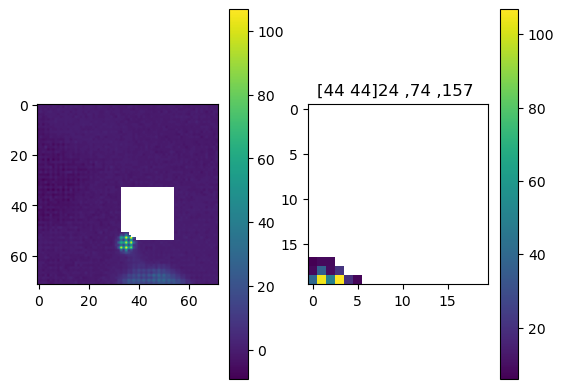

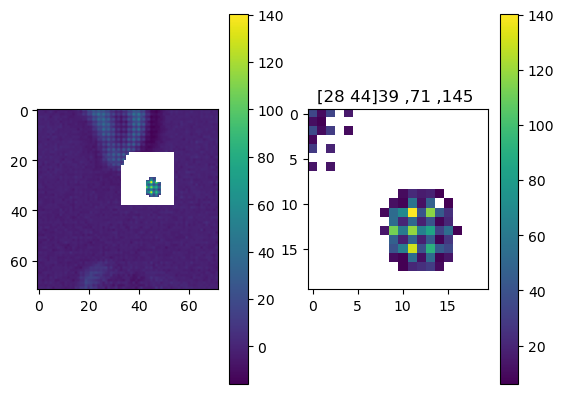

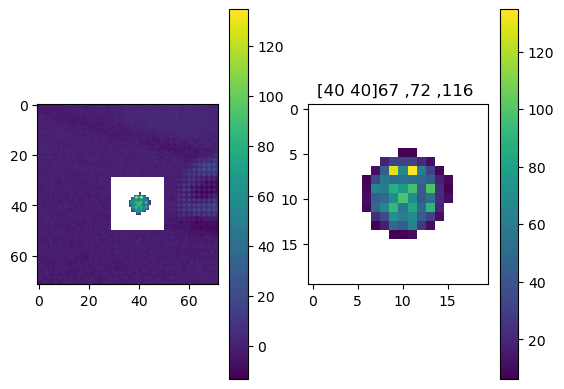

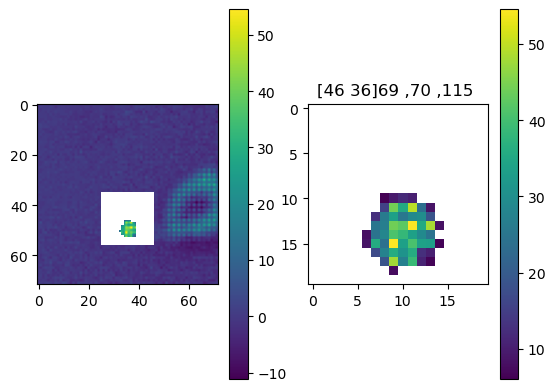

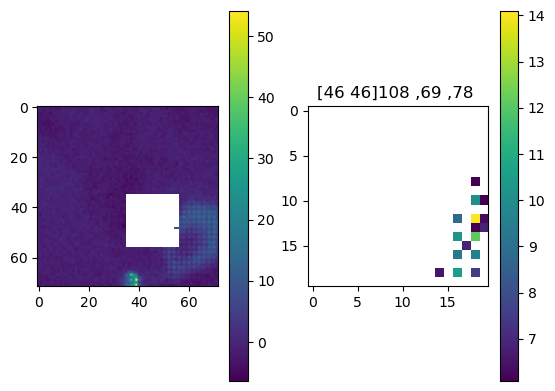

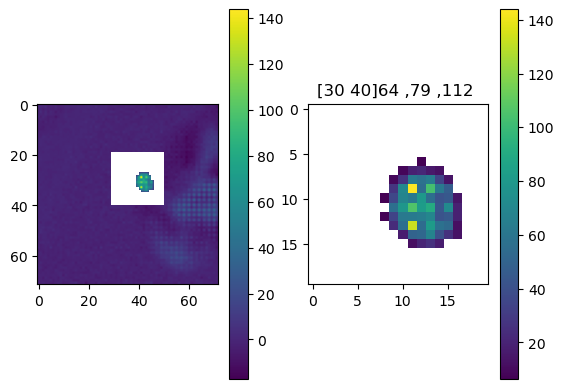

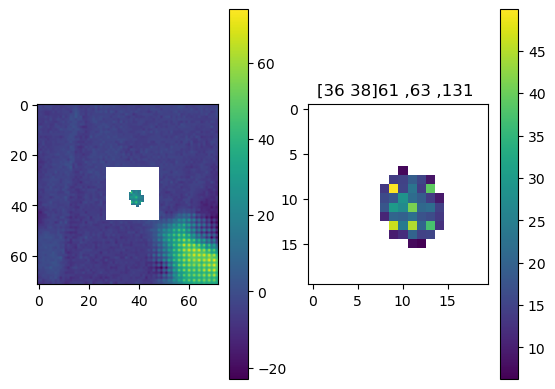

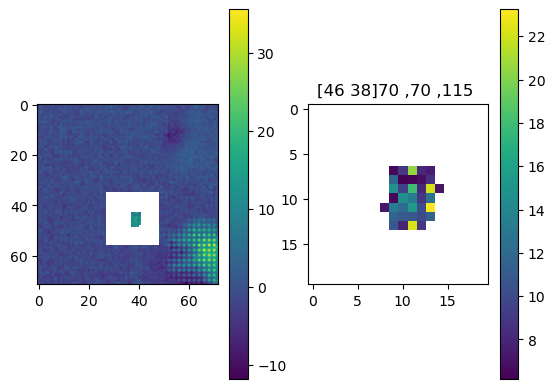

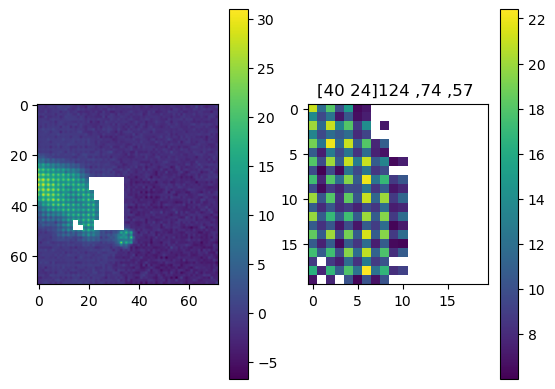

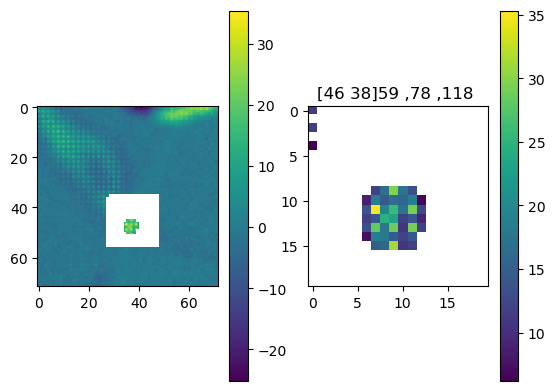

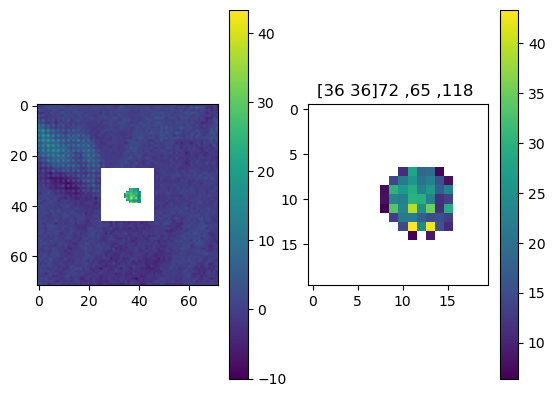

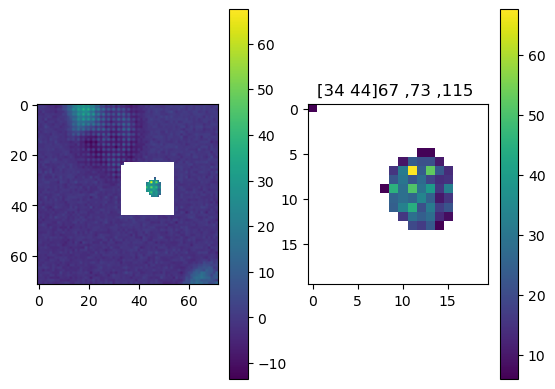

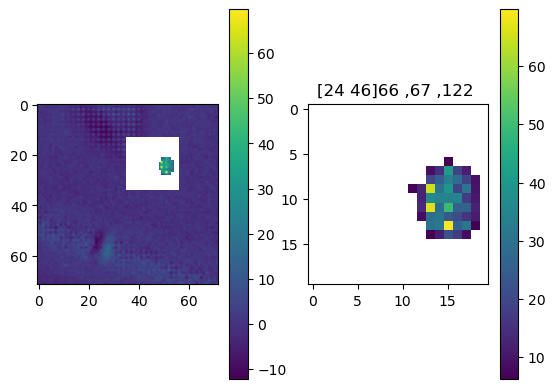

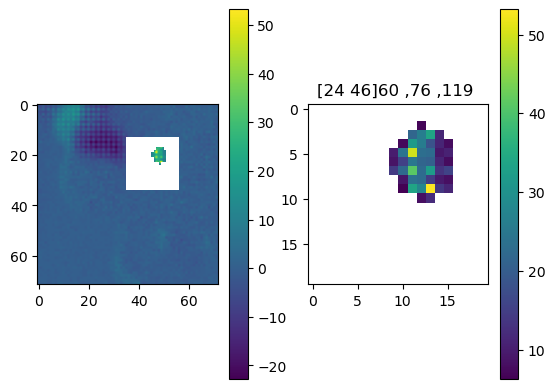

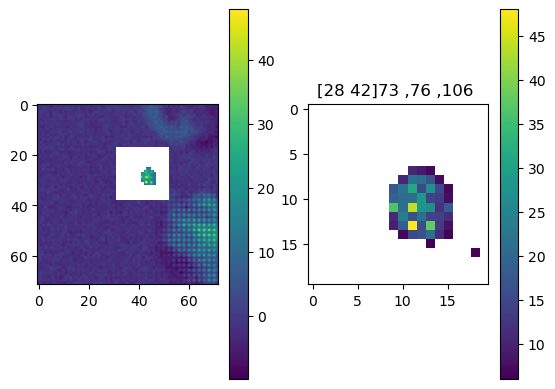

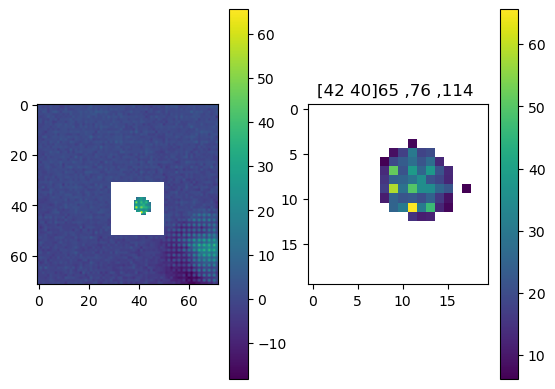

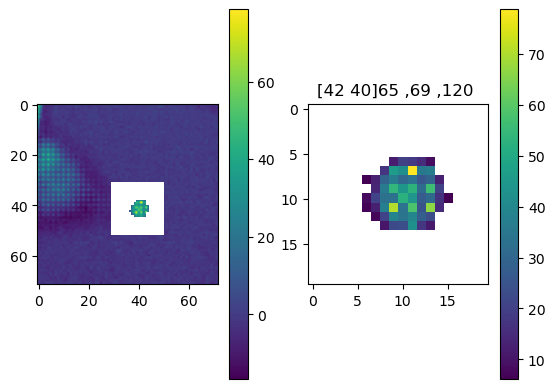

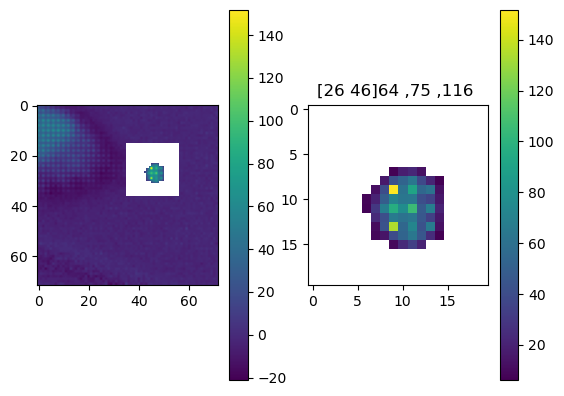

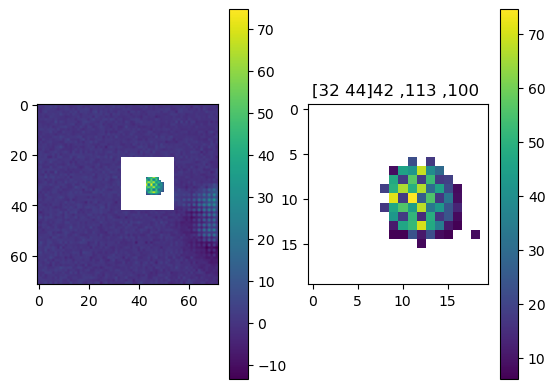

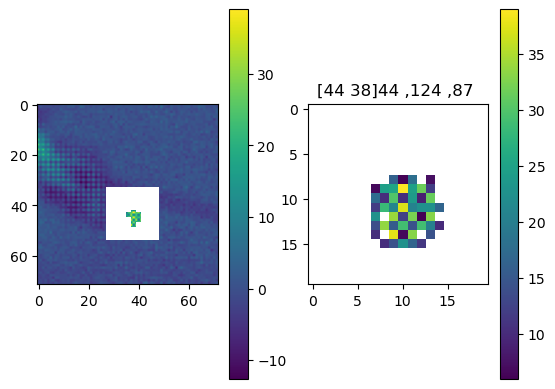

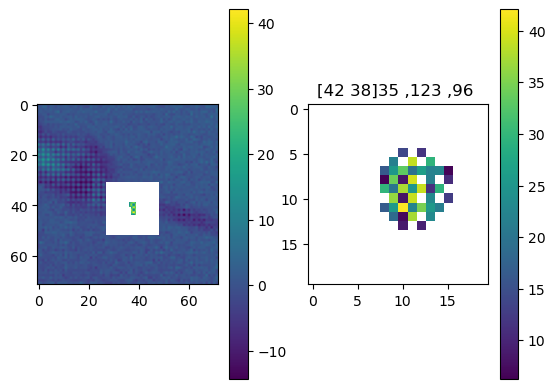

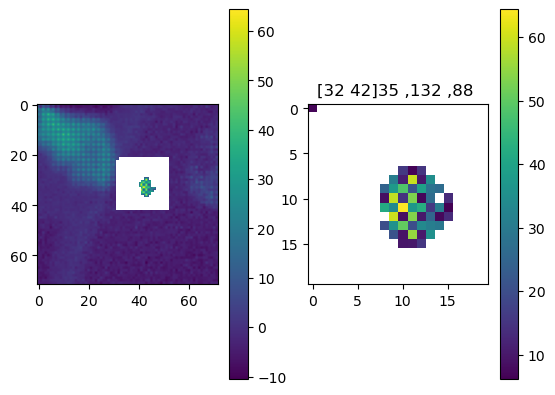

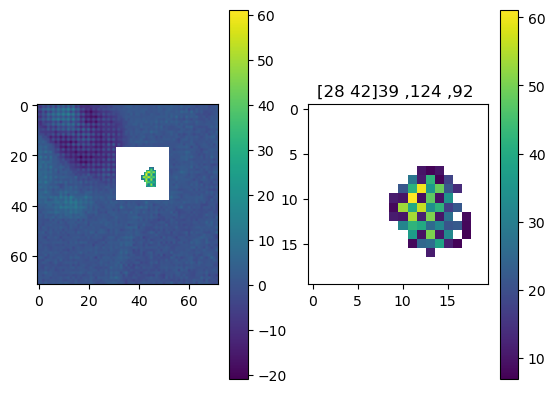

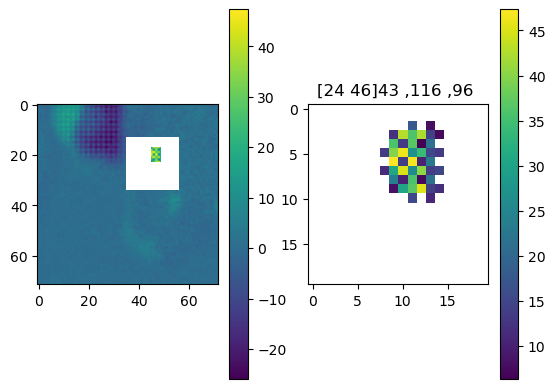

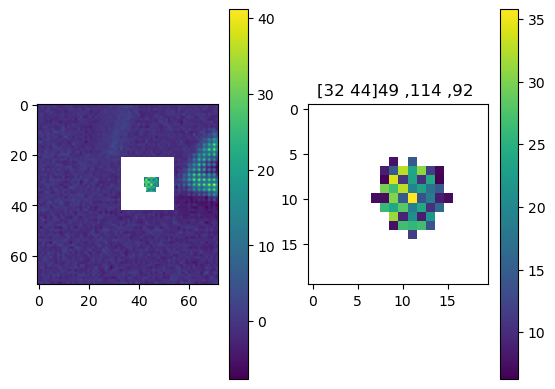

In [234]:
import os
from glob import glob
import json
import re
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
#pathtodata = '/home/mike/temp/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact'
#pathtodata = '/home/mike/temp/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1034/C-DA3075143'
#pathtodata = '/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1034/C-DA3075143'
pathtodata = '/home/mike/temp2/Microcolony_M4_M1p1_M1p2_compact/monitor_bees_3_compact/1035/C-DA3063854'
#compact_20250602_11+06+22.067514_5968.np

def totalsecs(st):
    try:
        time_hms = [int(s) for s in re.findall('([0-9]{1,2})[:+]([0-9]{2})[:+]([0-9]{2})',st)[0]]
    except TypeError as e:
        print("Tried to find time of format HH:MM:SS in '%s'" % st)
        raise e
    return time_hms[0]*3600 + time_hms[1]*60 + time_hms[2]

def getindex(st):
    try:
        index = int(fn.split(os.sep)[-1].split(".")[1].split('_')[-1])
    except:
        print("Tried to get index of image from filename '%s'" % st)
    return index
    
after = None #totalsecs("11:06:12")
before = None #totalsecs("11:06:22")

def isgreyscale(photoitem): #todo move these duplicated functions to some general bt... module?
    """
    Returns true if the photo item is from a greyscale camera
    TODO Need to add code to bee_track to record in the photoitem if it's greyscale. Currently a hack to try to guess from the image itself.   
    
    """
    print("Trying to determine if %s is greyscale..." % photoitem['filename'])
#    print(photoitem)
    if 'greyscale' in photoitem: 
        gs = photoitem['greyscale']
        print("Determined to be greyscale=%s from 'greyscale' photoitem feature" % ("True" if gs else "False"))
        return gs   
    gs = np.mean(np.abs(photoitem['img'][::2,::2].astype(float)-photoitem['img'][1::2,1::2].astype(float)))/np.mean(photoitem['img'][::2,::2].astype(float))<1
    
#    print(np.mean(np.abs(photoitem['img'][1:-1:2,:].astype(float)-photoitem['img'][0:-2:2,:]/2-photoitem['img'][2::2,:]/2))/np.mean(photoitem['img']))
#    print(np.mean(np.abs(photoitem['img'][1::2,1::2].astype(float)-photoitem['img'][1::2,::2])))
#    print(np.mean(np.abs(photoitem['img'][::2,1::2].astype(float)-photoitem['img'][1::2,::2])))    
    print("Determined to be greyscale=%s from photoitem img" % ("True" if gs else "False"))
    return gs   

def load_photoitem_associated_with_json(json_filename):
    pathtoimgfile = os.path.normpath(json_filename).split(os.path.sep)
    pathtoimgfile[-1] = pathtoimgfile[-1][:-4]+'np'
    del pathtoimgfile[-2]
    photo_item = np.load(os.sep.join(pathtoimgfile),allow_pickle=True)
    return photo_item

#we end up with 2x more green, but this is just for finding the tag etc, so not a big deal
#tag[50,20]=30
def get_tag_colour(tag,debugimgfn=None):
    """
    Pass this function the patch image
    Returns RGB tuple TODO !!! Confirm ORDER!!
    """
    offsetshift = 24
    offsetshiftb = 10
    #temptag = tag[16:-16,16:-16].copy()
    temptag = tag[24:-24,24:-24].copy()
    greytag = np.mean(temptag.reshape(temptag.shape[0]//2,2,temptag.shape[1]//2,2),axis=(1,3))
    coords = np.array(np.unravel_index(greytag.argmax(),greytag.shape))*2+offsetshift
    #coords = np.array([int(np.median(np.where(greytag>2)[0]))*2,int(np.median(np.where(greytag>2)[1]))*2])+16
    temptag = tag[coords[0]-offsetshiftb:coords[0]+offsetshiftb,coords[1]-offsetshiftb:coords[1]+offsetshiftb]
    temptag[temptag<6]=np.nan #ignore dim pixels!! [these are probably surrounding the tag]
    if np.sum(np.isnan(temptag))<25: return None #failed to decode colour
    rgb = np.array([np.nanmean(temptag[::2,::2]),(np.nanmean(temptag[1::2,::2])+np.nanmean(temptag[::2,1::2]))/2,np.nanmean(temptag[1::2,1::2])])
    rgb/=np.sum(rgb)
    rgb*=255
    if np.any(np.isnan(rgb)): return None
    rgb = tuple(rgb)
    if debugimgfn is not None:
        plt.figure()
        plt.subplot(1,2,1)
        plt.imshow(tag)
        plt.colorbar()
        plt.subplot(1,2,2)
        plt.imshow(temptag)
        plt.colorbar()
        plt.title(str(coords)+",".join(["%0.0f " % c for c in rgb]))
        plt.savefig(debugimgfn)
    return rgb

temp = []
patches = []
for root, dirs, files in os.walk(pathtodata):
    print("root:")
    print(root)
    #if 'btretrodetect' in root:
    if 'btviewer_copy' in root:
        pathtoimages = os.path.dirname(root)
        print("--------")
        print(pathtoimages)
        fn = sorted(glob(pathtoimages+'/*.np'))[0]
        try:
            photoitem = np.load(fn,allow_pickle=True)
        except Exception as e:# UnpicklingError:
            print("Failed to unpickle '%s'." % fn)
            print(e)
            continue
        #print(fn)
        if isgreyscale(photoitem):
            print("Greyscale...") # TODO Feed the output from the colour one to the greyscale one?
            continue

        fullimages = []

        for fn in sorted(glob(pathtoimages+'/*.np')):
            #b
            #print(fn,getindex(fn))
            if getindex(fn)%100==0:
                
                possible_fullimage = np.load(fn,allow_pickle=True)
                if possible_fullimage['img'] is not None:
                    print("FOUND FULL IMAGE")
                    fullimages.append(possible_fullimage)
                if len(fullimages)>10:
                    del fullimages[0]
        
                
        #Now we loop just over the json labels, and look at those images...
        for fn in sorted(glob(root+'/*.json')):
            #print("%d " % getindex(fn), end="")

            if before is not None and after is not None:
                if not before>=totalsecs(fn)>=after:
                    continue
            #print("Processing %s" % fn)
            jsondata = json.load(open(fn,'rb'))
            #print(fn[-10:],end="")
            if len(jsondata)==0: #no point loading image...
                res = []
                #print(" N")
                continue
            #else:
                
                #print(" Y")
            #phototiem = np.load(fn
            
            #print(fn,tag['x'])
            try:
                photo_item = load_photoitem_associated_with_json(fn)
            except Exception as e:
                print("Failed to load image associated with %s" % fn)
                print(e)
                continue
            #temp.append({'photo_item':photo_item,'jsondata':jsondata})

            fullimage = np.median(np.array([fi['img'] for fi in fullimages]),0)

            
            newjsonfn = fn.split(os.sep)
            newjsonfn[-2]='btcolor'
            newjsonfn = os.sep.join(newjsonfn)

            debugimgfn = fn.split(os.sep)
            debugimgfn[-2]='btcolor'
            debugimgfn = os.sep.join(debugimgfn)
            debugimgfn = debugimgfn[:-4]+'png'
            
            newjsonpath = os.sep.join(newjsonfn.split(os.sep)[:-1])
            Path(newjsonpath).mkdir(parents=True, exist_ok=True)
            
            patches = []
            #plt.figure()
            for p in photo_item['imgpatches']:
                
                
                
                x = p['x']
                y = p['y']
                #print(x,y,np.array([[d['x'],d['y']] for d in jsondata]))
                #
                dists = np.sum((np.array([x,y])-np.array([[d['x'],d['y']] for d in jsondata]))**2,1)
                #print(dists)
                if np.all(dists>25): continue
                
                
                ps = p['raw_patch'].shape[0]//2
                patchbg = fullimage[y-ps:y+ps,x-ps:x+ps].astype(float)
                pimg = p['raw_patch'].astype(float)
                temp_normalising_pimg = pimg.copy()
                temp_normalising_patchbg = patchbg.copy()
                cropsize = 25
                temp_normalising_pimg[ps-cropsize:ps+cropsize,ps-cropsize:ps+cropsize] = np.NaN
                temp_normalising_patchbg[ps-cropsize:ps+cropsize,ps-cropsize:ps+cropsize] = np.NaN
                brightness_scale = np.nanmean(temp_normalising_pimg)/np.nanmean(temp_normalising_patchbg)
                patchbg*=brightness_scale
                temp_normalising_patchbg*=brightness_scale
                tag = pimg-patchbg   
                rgb = get_tag_colour(tag,debugimgfn=debugimgfn)
                if rgb is None:
                    patches.append({'source': 'btcolor','x':int(x),'y':int(y),'r':0,'g':0,'b':0,'label':'??'})
                else:
                    st = "%0.0f %0.0f %0.0f" % rgb
                    patches.append({'source': 'btcolor','x':int(x),'y':int(y),'r':int(rgb[0]),'g':int(rgb[1]),'b':int(rgb[2]),'label':st})
            
            
            json.dump(patches,open(newjsonfn,'w'))

array([[1217,  659]])

In [125]:
greytag[10,:]

array([-4.84413197, -3.96722212, -2.59413197, -1.34795168, -2.06813407,
       -0.47868125,  0.92804622,  4.11459129,  2.95786383,  4.20786383,
        3.24150115,  3.42804622,  2.64822861,  2.92804622,  1.45786383,
       -0.48250095, -0.11323052,  0.03967723, -0.55741501,  0.15894767])

(10, 9)

In [46]:
photo_item['filename']

'20250602_11+06+22.067514_5968.np'

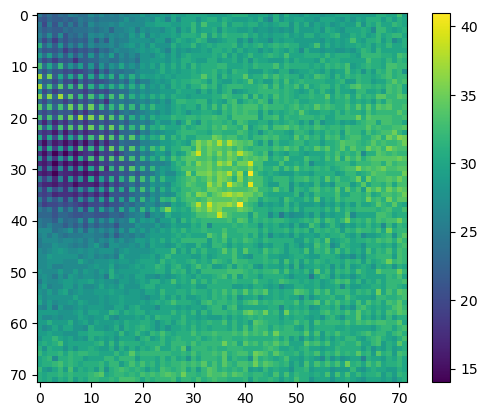

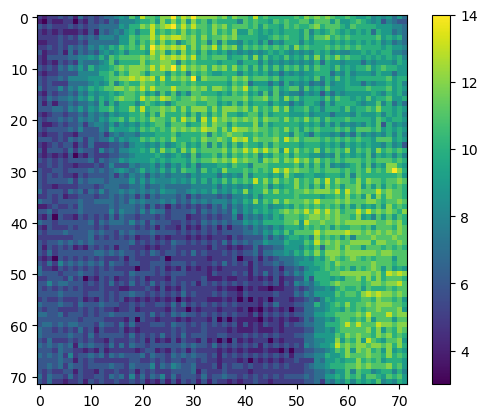

In [35]:
import matplotlib.pyplot as plt
for p in photo_item['imgpatches']:
    plt.figure()
    plt.imshow(p['raw_patch'])
    plt.colorbar()

In [72]:
##for fn in sorted(glob(os.path.sep.join(os.path.normpath(fn).split(os.path.sep)[:-2]+['*.np']))):
##    print(fn)